In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from typing import Optional
import torch.nn.functional as F

from model import Transformer, make_src_mask, make_tgt_mask

from tqdm import tqdm
from nltk.translate.bleu_score import corpus_bleu

from dataset import *
from lr_scheduler import *
from train import *

import wandb

In [ ]:
transformer = run_training_experiment()

In [2]:
config = {
        "grid_size"        : 128,
        "patch_size"       : 4,
        "patch_dim"        : 4 * 4 * 2,
        "d_model"          : 256,
        "N"                : 8,
        "num_heads"        : 8,
        "d_ff"             : 1024,
        "dropout"          : 0.1,
        "train_batch_size" : 2,
        "test_batch_size"  : 32,
        "epochs"           : 15,
        "device"           : 'cuda' if torch.cuda.is_available() else 'cpu',
        'save_every'       : 4,
    }

transformer = Transformer(
                        d_model        = config["d_model"], 
                        N              = config["N"], 
                        num_heads      = config["num_heads"], 
                        d_ff           = config["d_ff"],
                        patch_dim      = config['patch_dim'])

In [3]:
load_checkpoint("checkpoint-2.pt", transformer)

99

In [4]:
cfd_dataset   = CFD_Dataset(root = "Data", patch_size = 4, grid_size = 128)
dataloader    = DataLoader(cfd_dataset, batch_size = 1, shuffle = True)

src, tgt = next(iter(dataloader))

pred_patches = greedy_decode(transformer, src, src_mask=make_src_mask(src, -1), max_len = (config["grid_size"]//config["patch_size"])**2, patch_dim = config["patch_dim"])
pred_patches.shape

100%|██████████| 1024/1024 [05:09<00:00,  3.31it/s]


torch.Size([1, 1024, 32])

In [5]:
src, tgt = next(iter(dataloader))

In [6]:
def patches_to_contour(patch, num_patches, patch_size, grid_size):

    unrolled = patch.view(num_patches, num_patches, 2, patch_size, patch_size)   # (patch_row, patch_col, C, patch_h, patch_w)
    unrolled = unrolled.permute(2, 0, 3, 1, 4).contiguous()                      # (C, patch_row, patch_h, patch_col, patch_w)
    unrolled = unrolled.view(2, grid_size, grid_size)                            # (2, grid_size, grid_size)

    return unrolled

In [7]:
config["patch_size"]

4

In [9]:
pred_patches.shape

torch.Size([1, 1024, 32])

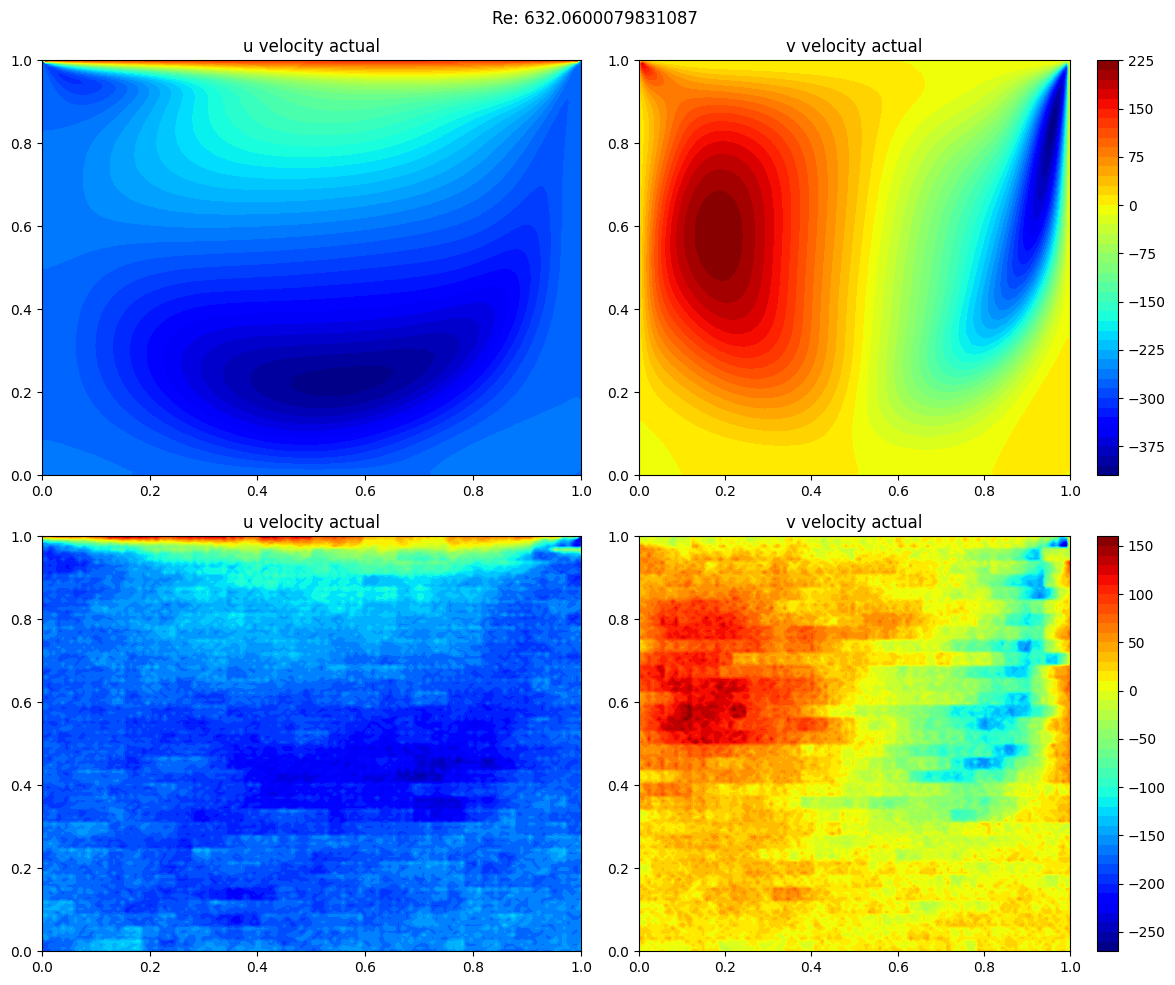

In [11]:
patches = tgt[0] # remove B for now
re = src[0]      # remove B for now

unrolled_actual = patches_to_contour(patches, config["grid_size"]//config["patch_size"], config["patch_size"], config["grid_size"])
unrolled_pred = patches_to_contour(pred_patches[0], config["grid_size"]//4, 4, config["grid_size"])

u_actual = unrolled_actual[0]                                                 # (grid_size, grid_size)
v_actual = unrolled_actual[1]                                                 # (grid_size, grid_size)

u_pred = unrolled_pred[0]                                                 # (grid_size, grid_size)
v_pred = unrolled_pred[1]                                                 # (grid_size, grid_size)

x_grid = torch.linspace(0, 1, 128)
y_grid = torch.linspace(0, 1, 128)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].contourf(x_grid, y_grid, (u_actual * cfd_dataset.u_std) + cfd_dataset.u_mean, levels=50, cmap="jet")
axes[0, 0].set_title("u velocity actual")
c1 = axes[0, 1].contourf(x_grid, y_grid, (v_actual * cfd_dataset.v_std) + cfd_dataset.v_mean, levels=50, cmap="jet")
fig.colorbar(c1)
axes[0, 1].set_title("v velocity actual")

axes[1, 0].contourf(x_grid, y_grid, ((u_pred * cfd_dataset.u_std) + cfd_dataset.u_mean).detach().cpu().numpy(), levels=50, cmap="jet")
axes[1, 0].set_title("u velocity actual")
c2 = axes[1, 1].contourf(x_grid, y_grid, ((v_pred * cfd_dataset.v_std) + cfd_dataset.v_mean).detach().cpu().numpy(), levels=50, cmap="jet")
fig.colorbar(c2)
axes[1, 1].set_title("v velocity actual")


plt.suptitle(f"Re: {(re.item() * cfd_dataset.re_std) + cfd_dataset.re_mean}")

plt.tight_layout()
plt.show()

Max divergence actual: 2.7353523
Max divergence pred: 1.1056279

Mean divergence actual: 0.038896836
Mean divergence pred: 0.038896836


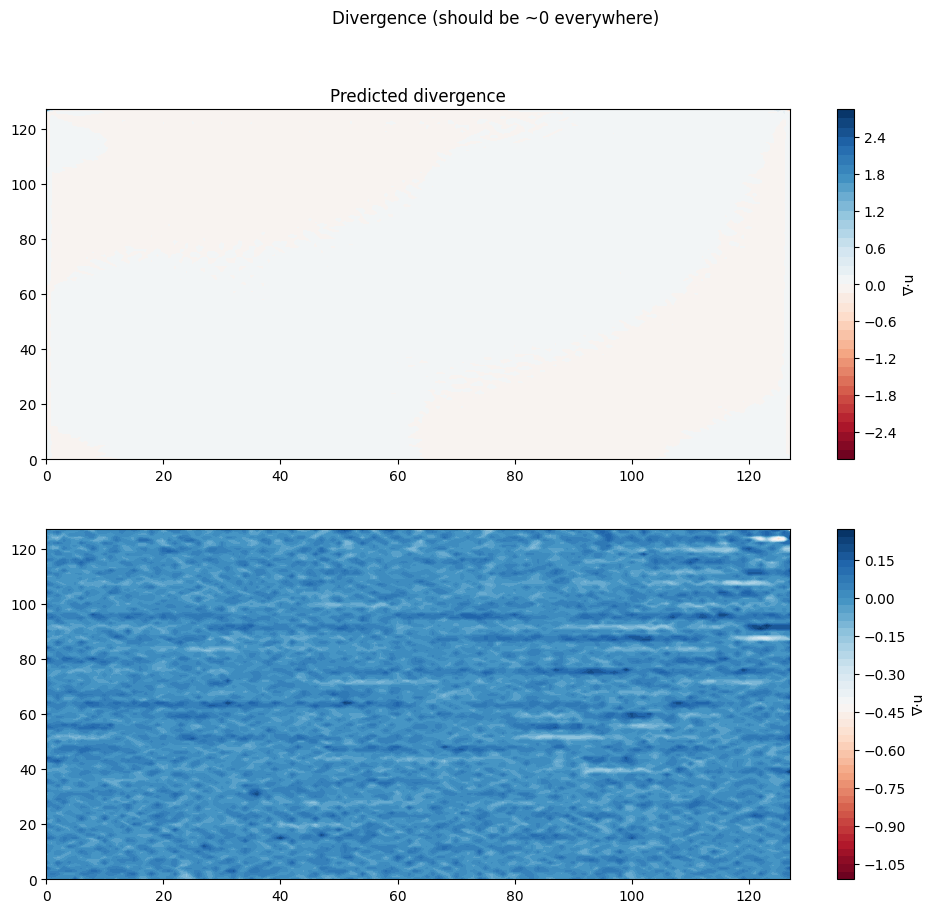

In [12]:
u_np = u_actual.detach().numpy()
v_np = v_actual.detach().numpy()

u_np_pred = u_pred.detach().numpy()
v_np_pred = v_pred.detach().numpy()

# numerical gradients
du_dx = np.gradient(u_np, axis=1)  # derivative along x (cols)
dv_dy = np.gradient(v_np, axis=0)  # derivative along y (rows)

du_dx_pred = np.gradient(u_np_pred, axis=1)  # derivative along x (cols)
dv_dy_pred = np.gradient(v_np_pred, axis=0)  # derivative along y (rows)

divergence = du_dx + dv_dy
divergence_pred = du_dx_pred + dv_dy_pred

print("Max divergence actual:", np.abs(divergence).max())
print("Max divergence pred:", np.abs(divergence_pred).max())

print("\nMean divergence actual:", np.abs(divergence_pred).mean())
print("Mean divergence pred:", np.abs(divergence_pred).mean())

fig, axes = plt.subplots(2, figsize=(12, 10))

c1 = axes[0].contourf(divergence, levels=50, cmap="RdBu")
axes[0].set_title("Actual divergence")
plt.colorbar(c1, label="∇·u")

c2 = axes[1].contourf(divergence_pred, levels=50, cmap="RdBu")
axes[0].set_title("Predicted divergence")
plt.colorbar(c2, label="∇·u")

plt.suptitle("Divergence (should be ~0 everywhere)")
plt.show()

100%|██████████| 1024/1024 [03:11<00:00,  5.34it/s]


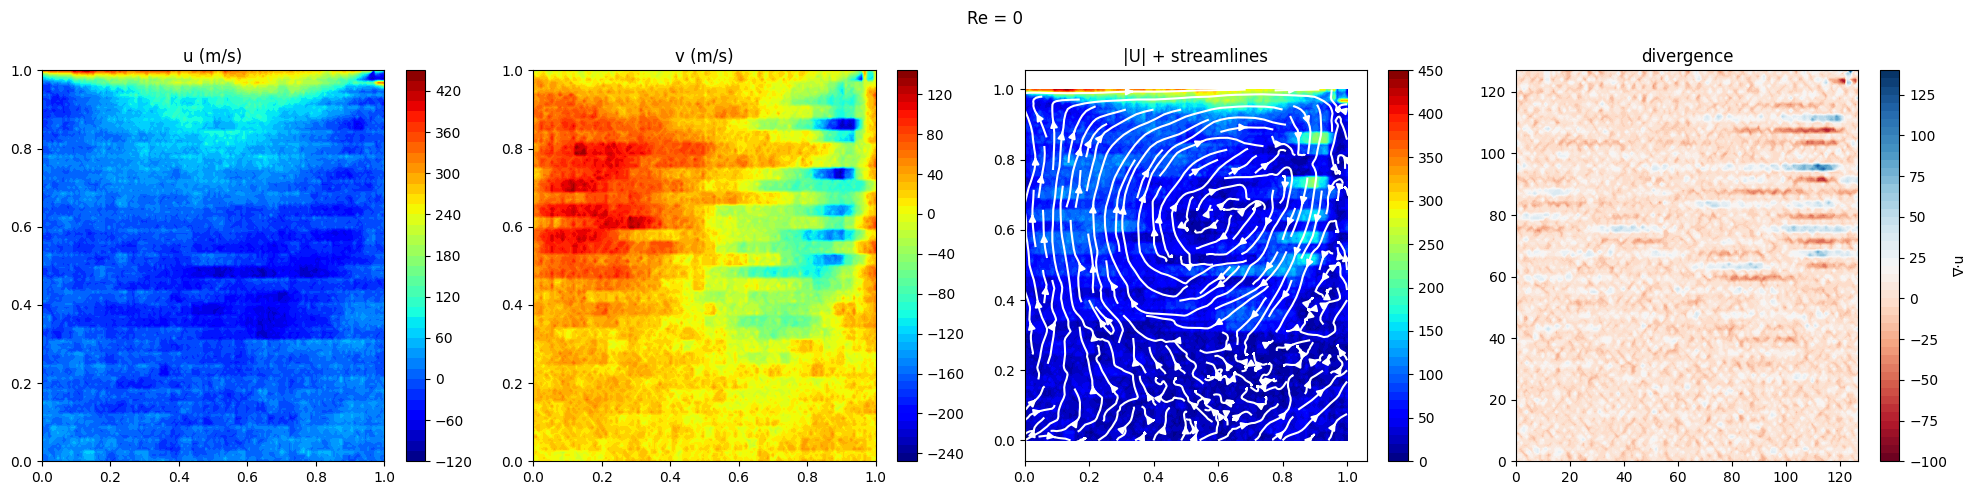

100%|██████████| 1024/1024 [04:25<00:00,  3.85it/s]


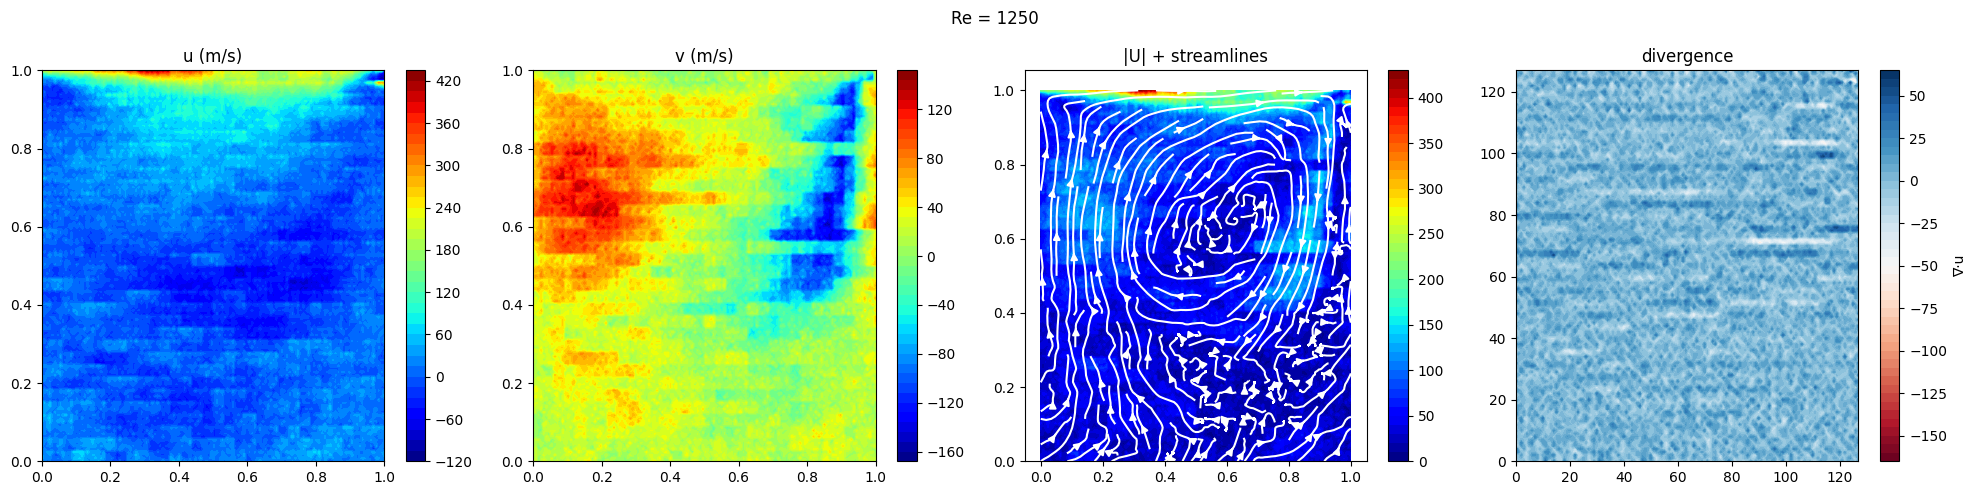

100%|██████████| 1024/1024 [04:01<00:00,  4.24it/s]


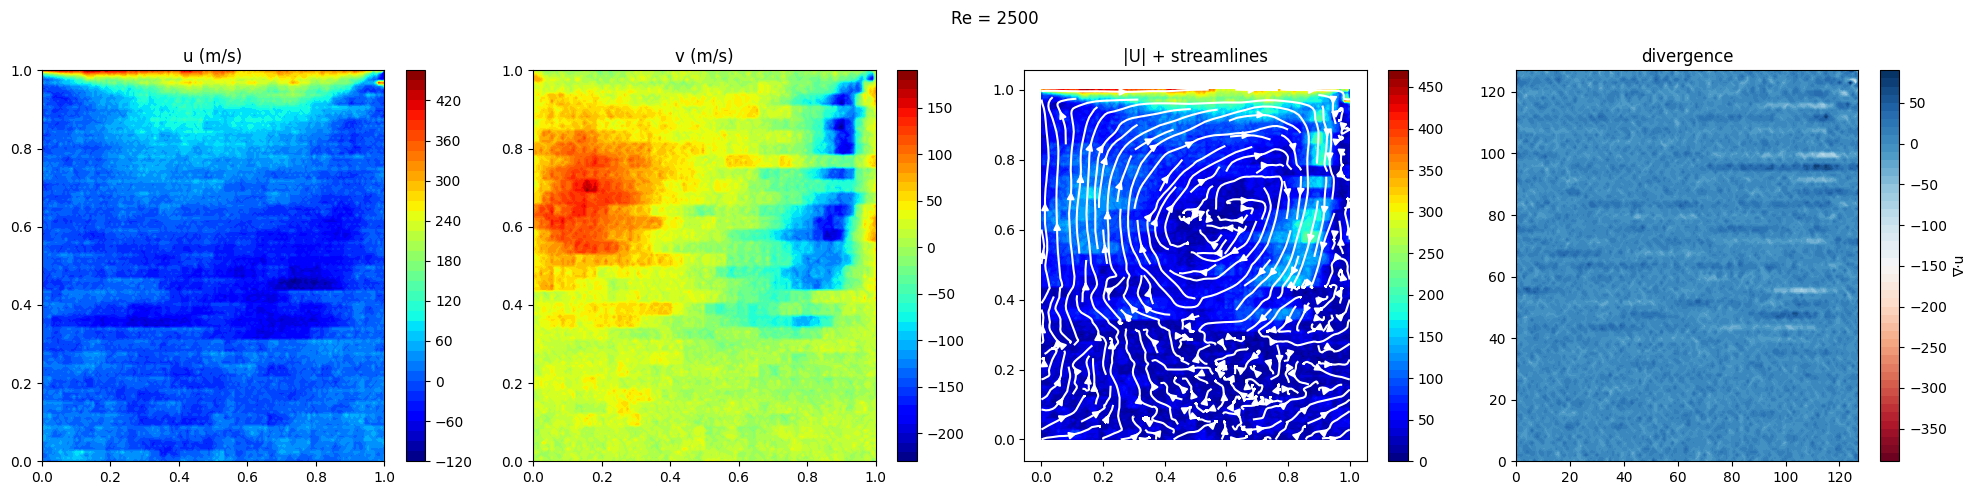

In [ ]:
def predict_for_re(re_value, model, cfd_dataset, config, device="cpu"):
    # normalize using dataset stats
    re_norm = (re_value - cfd_dataset.re_mean) / cfd_dataset.re_std
    src = torch.tensor([[re_norm]], dtype=torch.float32).to(device)  # (1, 1)

    # decode
    src_mask = make_src_mask(src, -1)
    pred_patches = greedy_decode(
        model, src, src_mask,
        max_len  = (config["grid_size"] // config["patch_size"])**2,
        patch_dim = config["patch_dim"],
        device   = device
    )  # (1, num_patches, patch_dim)

    # unroll patches to (2, 64, 64)
    unrolled = patches_to_contour(pred_patches[0], 
                                   config["grid_size"] // config["patch_size"], 
                                   config["patch_size"], 
                                   config["grid_size"])

    u = unrolled[0].detach().cpu()
    v = unrolled[1].detach().cpu()

    # denormalize
    u = (u * cfd_dataset.u_std) + cfd_dataset.u_mean
    v = (v * cfd_dataset.v_std) + cfd_dataset.v_mean

    # plot
    x_grid = np.linspace(0, 1, config["grid_size"])
    y_grid = np.linspace(0, 1, config["grid_size"])

    mag = np.sqrt(u**2 + v**2)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    c0 = axes[0].contourf(x_grid, y_grid, u, levels=50, cmap="jet")
    fig.colorbar(c0, ax=axes[0])
    axes[0].set_title("u (m/s)")

    c1 = axes[1].contourf(x_grid, y_grid, v, levels=50, cmap="jet")
    fig.colorbar(c1, ax=axes[1])
    axes[1].set_title("v (m/s)")

    c2 = axes[2].contourf(x_grid, y_grid, mag, levels=50, cmap="jet")
    fig.colorbar(c2, ax=axes[2])
    axes[2].streamplot(x_grid, y_grid, u.numpy(), v.numpy(), color="white", density=1.2)
    axes[2].set_title("|U| + streamlines")

    # numerical gradients
    u_np = u.numpy()
    v_np = v.numpy()
    du_dx = np.gradient(u_np, axis=1)  # derivative along x (cols)
    dv_dy = np.gradient(v_np, axis=0)  # derivative along y (rows)

    divergence = du_dx + dv_dy

    c3 = axes[3].contourf(divergence, levels=50, cmap="RdBu")
    plt.colorbar(c3, label="∇·u")
    axes[3].set_title("divergence")

    plt.suptitle(f"Re = {re_value}")
    plt.tight_layout()
    plt.show()

    return u, v, divergence

# Re can be inside or outside training range
u, v, divergence = predict_for_re(0, transformer, cfd_dataset, config, device=config["device"])
u, v, divergence = predict_for_re(1250, transformer, cfd_dataset, config, device=config["device"])
u, v, divergence = predict_for_re(2500,  transformer, cfd_dataset, config, device=config["device"])

In [40]:
divergence.min()

-332.8983

In [5]:
import torch

patches_per_side = 64 // 8
coords = []
for row in range(patches_per_side):
    for col in range(patches_per_side):
        coords.append([(col+0.5)/patches_per_side, (row+0.5)/patches_per_side])
coords_tensor = torch.tensor(coords, dtype=torch.float32)

coords_tensor.shape

torch.Size([64, 2])

In [ ]:
def fourier_features(cords, num_freq):
    # [num_patches, 2] -> [num_patches, C * num_freq * 2]
    freqs = 2 ** torch.linspace(0, num_freq - 1, num_freq)                   # [num_freqs]
    angles = (coords_tensor.unsqueeze(-1) * freqs * 2 * torch.pi)            # [num_patches, C, num_freq]
    encoded = torch.cat([torch.sin(angles), torch.cos(angles)], dim = -1)    # [num_patches, C, num_freq * 2]
    return encoded.view(cords.shape[0], -1)                                  # [num_patches, C * num_freq * 2]


In [4]:
def patches_to_contour(patch, num_patches, patch_size, grid_size):

    unrolled = patch.view(num_patches, num_patches, 2, patch_size, patch_size)   # (patch_row, patch_col, C, patch_h, patch_w)
    unrolled = unrolled.permute(2, 0, 3, 1, 4).contiguous()                      # (C, patch_row, patch_h, patch_col, patch_w)
    unrolled = unrolled.view(2, grid_size, grid_size)                            # (2, grid_size, grid_size)

    return unrolled

In [2]:
cfd_dataset = CFD_Dataset(root = "Data", patch_size = 8, grid_size = 64)
dataloader  = DataLoader(cfd_dataset, batch_size = 1, shuffle = True)

In [3]:
print("re_mean:", cfd_dataset.re_mean)
print("re_std:", cfd_dataset.re_std)
print("sorted Re:", sorted(cfd_dataset.re_list)[:10])

# what does re_norm look like for low Re?
for re in [100, 250, 500, 1000, 2500, 5000]:
    re_norm = (re - cfd_dataset.re_mean) / cfd_dataset.re_std
    weight  = 1.0 + np.exp(-re_norm)
    print(f"Re={re:5.0f} -> re_norm={re_norm:.2f} -> weight={weight:.2f}")

re_mean: 1250.4998400000002
re_std: 728.6498136046933
sorted Re: [1.0, 26.242, 51.485, 76.727, 101.97, 127.21, 152.45, 177.7, 202.94, 228.18]
Re=  100 -> re_norm=-1.58 -> weight=5.85
Re=  250 -> re_norm=-1.37 -> weight=4.95
Re=  500 -> re_norm=-1.03 -> weight=3.80
Re= 1000 -> re_norm=-0.34 -> weight=2.41
Re= 2500 -> re_norm=1.71 -> weight=1.18
Re= 5000 -> re_norm=5.15 -> weight=1.01


In [4]:
re_arr = np.array(sorted(cfd_dataset.re_list))
print("min Re:", re_arr.min())
print("max Re:", re_arr.max())
print("num samples below 500:", (re_arr < 500).sum())
print("num samples above 500:", (re_arr >= 500).sum())

min Re: 1.0
max Re: 2500.0
num samples below 500: 20
num samples above 500: 80


In [21]:
re = torch.tensor([1, 100, 200, 300])
re_norm = (re - cfd_dataset.re_mean) / cfd_dataset.re_std

re_norm

tensor([-1.7148, -1.5789, -1.4417, -1.3045])

In [37]:
cfd_dataset.re_mean

1250.4998400000002

In [27]:

re_actual = (re_norm * cfd_dataset.re_std + cfd_dataset.re_mean)
weights = torch.log(torch.tensor(2500.0) + 1) / torch.log(re_actual + 1)

weights   = weights / weights.mean()
weights

tensor([2.8524, 0.4284, 0.3728, 0.3464])

In [ ]:
torch.rand((1,1,10,3)).mean(dim = [1,2,3])

tensor([0.4670])

In [ ]:
# replace this
# re_weight = 1.0 + torch.exp(-re_norm).mean()


# with this
re_actual = (re_norm.squeeze() * cfd_dataset.re_std + cfd_dataset.re_mean)
weights   = torch.log(torch.tensor(2500.0) + 1) / torch.log(re_actual + 1)
weights   = weights / weights.mean()
mse_per_sample = ((pred_field - target_field)**2).mean(dim=[1,2,3])
mse_loss       = (mse_per_sample * weights.to(pred.device)).mean()

In [ ]:
# take actual patches, reconstruct, compare to original grid
src, tgt = next(iter(dataloader))

Re = 935


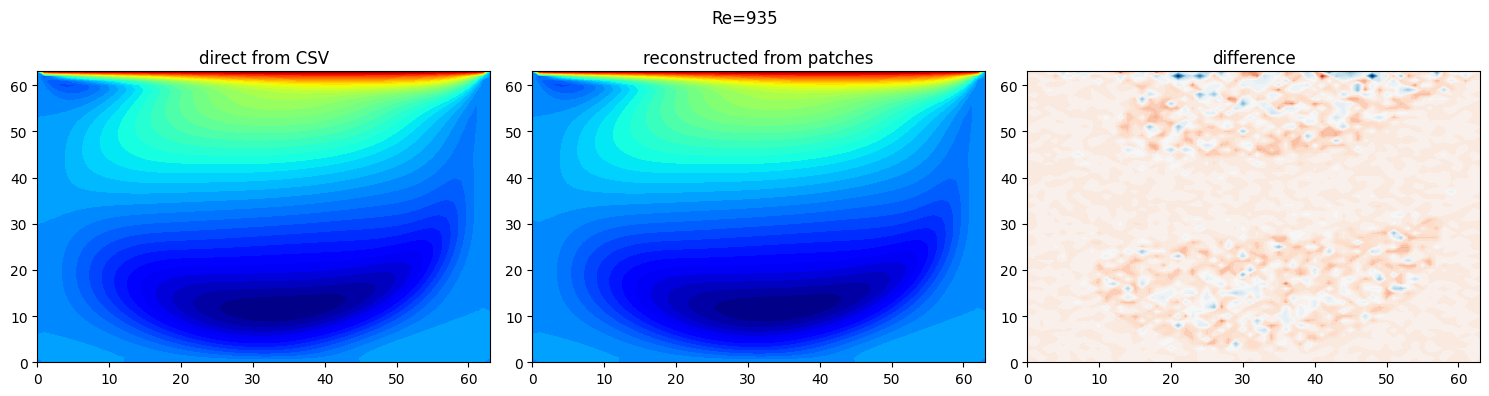

max diff: 8.788450202246167e-05
mean diff: 5.237703830256034e-06


In [10]:

# get the Re value
re_val = (src[0].item() * cfd_dataset.re_std) + cfd_dataset.re_mean
print(f"Re = {re_val:.0f}")
re_val = 934.97

# reconstruct from patches
patches = tgt[0][:, :-64]  # strip pos enc
unrolled = patches_to_contour(patches, 8, 8, 64)
u_from_patches = (unrolled[0] * cfd_dataset.u_std + cfd_dataset.u_mean).numpy()

# load the original CSV directly
import pandas as pd
from scipy.interpolate import griddata

df = pd.read_csv(f"Data/Re_{re_val}.csv", index_col=0).dropna()
x = df["x"].values.astype(np.float32)
y = df["y"].values.astype(np.float32)
u = df["u (m/s)"].values.astype(np.float32)

x = (x - x.min()) / (x.max() - x.min() + 1e-8)
y = (y - y.min()) / (y.max() - y.min() + 1e-8)

lin    = np.linspace(0, 1, 64)
grid_x, grid_y = np.meshgrid(lin, lin)
u_grid = griddata(np.stack([x, y], 1), u, (grid_x, grid_y), method="linear", fill_value=0.0)

# compare
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].contourf(u_grid, levels=50, cmap="jet")
axes[0].set_title("direct from CSV")

axes[1].contourf(u_from_patches, levels=50, cmap="jet")
axes[1].set_title("reconstructed from patches")

axes[2].contourf(u_grid - u_from_patches, levels=50, cmap="RdBu")
axes[2].set_title("difference")

plt.suptitle(f"Re={re_val:.0f}")
plt.tight_layout()
plt.show()

print("max diff:", np.abs(u_grid - u_from_patches).max())
print("mean diff:", np.abs(u_grid - u_from_patches).mean())

In [9]:
re_val

934.97